# 🌍 Swarm_Prediction — Notebook 1/3 · Pipeline de traitement des données

> **De la terre aux gens** — dans quelle mesure l'**environnement agricole** d'un pays
> (terre, climat, récoltes) détermine-t-il la **santé et la démographie** de sa population ?

Ce notebook documente **comment les données brutes deviennent un dataset modélisable**, sous-couche
par sous-couche, puis comment les couches se relient. C'est le **socle** : les notebooks 2 (exploration)
et 3 (modélisation) partent du dataset produit ici.

**Plan :** Stack technique · Architecture en couches · Sources par sous-couche · Pipeline de traitement
(collecte → nettoyage → enrichissement → fusion) · Variables produites · Anti-fuite · État d'avancement.

In [7]:
# --- Mise en place : se placer à la racine du projet ---
import os, sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == 'notebooks_presentation':
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', 60)
print('Racine projet :', ROOT)
print('pandas', pd.__version__, '| numpy', np.__version__)

Racine projet : c:\Users\louey\Swarm_Prediction_fix
pandas 2.2.3 | numpy 2.2.4


## 1. Stack technique

| Brique | Outils | Rôle |
|---|---|---|
| **Langage / calcul** | Python 3.13, **pandas**, **numpy** | manipulation tabulaire, jointures `(Pays, Année)` |
| **Collecte** | `requests`, APIs publiques (World Bank, FAO, OWID, NASA POWER…) | téléchargement reproductible |
| **Normalisation pays** | **pycountry**, **babel** | harmonisation des codes ISO (alpha-2 ↔ alpha-3) entre sources |
| **Modélisation** | **scikit-learn**, **XGBoost** | régression, pipelines, sélection de features |
| **Validation** | `GroupShuffleSplit` (split **par pays**) | éviter la fuite de données géographiques |
| **Visualisation** | **matplotlib**, **seaborn** | EDA et restitution |
| **Environnement** | **Jupyter**, `joblib` | notebooks, sérialisation des modèles |

> **Principe directeur :** *aucune donnée inventée*. Chaque variable provient d'une source publique et
> traçable ; chaque modèle est évalué honnêtement (test sur des **pays jamais vus**).

## 2. Architecture en couches

Le projet est construit en **couches thématiques** reliées par une clé commune **`(Pays, Année)`** :

```
   COUCHE 1 — LA PLANÈTE                          COUCHE 2 — LE SANG
   environnement & production                     démographie & santé
   10 sous-couches · 1071 features                3 sous-couches
   ├─ Céréales & racines      ├─ Élevage          ├─ Démographie
   ├─ Oléagineux              ├─ Env. physique     ├─ Santé (stunting)
   ├─ Fruits                  ├─ Écologie          └─ Catastrophes humaines
   ├─ Légumes                 ├─ Émissions atmo.
   ├─ Légumineuses            └─ Énergie
            └──────────────┐     clé      ┌──────────────┘
                           ▼  (Pays, Année) ▼
                  COUCHE SUPÉRIEURE — LE LIEN
        « la production de la terre explique la santé des gens »
```

- **Couche 1 « La Planète »** : on *prédit* l'état environnemental/agricole d'un pays à partir de sa
  géographie, son climat, ses sols. Elle produit **81 cibles** (rendements par culture, élevage, énergie,
  émissions, écologie…).
- **Couche 2 « Le Sang »** : on prédit la démographie/santé **uniquement** à partir des variables de la
  Couche 1 (les variables socio-économiques type PIB/HDI sont **blacklistées** par rigueur).
- **Couche supérieure (le lien)** : jointure analytique Couche 1 ⨝ Couche 2 sur `(Pays, Année)`.

In [8]:
# --- Chargement des deux datasets et de la structure des sous-couches ---
import importlib.util
def load_cfg(path, name):
    spec = importlib.util.spec_from_file_location(name, path)
    m = importlib.util.module_from_spec(spec); spec.loader.exec_module(m); return m
c1cfg = load_cfg('couche1_planete/config.py', 'c1cfg')
c2cfg = load_cfg('couche2_sang/config.py', 'c2cfg')

C1 = pd.read_csv('data/cleaned/dataset_final_v15_couche1.csv', low_memory=False)
C2 = pd.read_csv('data/couche2/dataset_couche2.csv', low_memory=False)

print(f"COUCHE 1 (La Planète) : {C1.shape[0]:>6} lignes × {C1.shape[1]:>4} colonnes "
      f"| {C1['ISO'].nunique()} pays | {int(C1['Annee'].min())}-{int(C1['Annee'].max())}")
print(f"COUCHE 2 (Le Sang)    : {C2.shape[0]:>6} lignes × {C2.shape[1]:>4} colonnes "
      f"| {C2['Code_Pays'].nunique()} pays | {int(C2['Annee'].min())}-{int(C2['Annee'].max())}")
print(f"\nCibles Couche 1 : {len([c for c in C1.columns if c.startswith('target_')])} "
      f"target_* réparties en {len(c1cfg.SUBLAYERS)} sous-couches (config officielle : 62)")
print(f"Cibles Couche 2 : {len([c for c in c2cfg.TARGETS])} en {len(c2cfg.SUBLAYERS)} sous-couches")

COUCHE 1 (La Planète) :   8400 lignes × 1157 colonnes | 240 pays | 1990-2024
COUCHE 2 (Le Sang)    :  14322 lignes ×   13 colonnes | 217 pays | 1960-2025

Cibles Couche 1 : 81 target_* réparties en 10 sous-couches (config officielle : 62)
Cibles Couche 2 : 10 en 3 sous-couches


## 3. Les sources, sous-couche par sous-couche

Chaque sous-couche agrège **plusieurs sources publiques**, harmonisées sur `(ISO pays, Année)`.

| Sous-couche (Couche 1) | Cibles | Sources principales |
|---|---|---|
| Céréales & racines | 2 | FAOSTAT (rendements, surfaces) |
| Oléagineux *(par culture)* | 8 | FAOSTAT par culture (soja, colza, tournesol…) |
| Fruits *(par culture)* | 16 | FAOSTAT par culture |
| Légumes *(par culture)* | 9 | FAOSTAT par culture |
| Légumineuses *(par culture)* | 3 | FAOSTAT par culture |
| Élevage | 8 | FAOSTAT (lait, viandes, œufs), OWID (aquaculture) |
| Environnement physique | 5 | WorldClim, NASA POWER, World Bank (eau, sols) |
| Écologie | 2 | Hansen/OWID (forêt, déforestation) |
| Émissions atmosphériques | 3 | OWID (CO₂, CH₄, N₂O) |
| Énergie | 6 | OWID / Ember (solaire, éolien, hydro, charbon, pétrole, gaz) |

**Features explicatives** (les entrées des modèles) — climat **WorldClim BIO 1-19**, **NASA POWER**,
**Berkeley Earth** ; sols & relief ; géologie (failles, séismes, volcans, minéraux) ; hydrologie ;
**Pew 2010** (religion) ; **NOAA** (ENSO/NAO/CO₂ Mauna Loa).

| Sous-couche (Couche 2) | Cibles | Sources |
|---|---|---|
| Démographie | 7 | **World Bank** (natalité, fécondité, mortalités, croissance, migration) |
| Santé | 1 | **FAO** (retard de croissance / stunting) |
| Catastrophes humaines | 2 | **EM-DAT / OWID** (décès & personnes affectées) |

In [9]:
# --- Table : sous-couche -> nombre de cibles présentes dans le dataset V15 ---
rows = []
for sub, tgts in c1cfg.SUBLAYERS.items():
    present = [t for t in tgts if t in C1.columns]
    rows.append({'Couche': '1 · Planète', 'Sous-couche': sub, 'Cibles définies': len(tgts),
                 'Présentes V15': len(present)})
for sub, tgts in c2cfg.SUBLAYERS.items():
    rows.append({'Couche': '2 · Sang', 'Sous-couche': sub, 'Cibles définies': len(tgts),
                 'Présentes V15': '—'})
tbl = pd.DataFrame(rows)
display(tbl)
print(f"\nTotal cibles Couche 1 définies en config : {sum(len(v) for v in c1cfg.SUBLAYERS.values())}")

,Couche,Sous-couche,Cibles définies,Présentes V15
0,1 · Planète,Céréales & racines,2,2
1,1 · Planète,Oléagineux (par culture),8,8
2,1 · Planète,Fruits (par culture),16,16
3,1 · Planète,Légumes (par culture),9,9
4,1 · Planète,Légumineuses (par culture),3,3
5,1 · Planète,Élevage,8,8
6,1 · Planète,Environnement physique,5,5
7,1 · Planète,Écologie,2,2
8,1 · Planète,Émissions atmosphériques,3,3
9,1 · Planète,Énergie,6,6



Total cibles Couche 1 définies en config : 62


## 4. Le pipeline de traitement

Le même squelette s'applique à chaque sous-couche, puis on **fusionne** :

```
 ┌────────────┐   ┌────────────┐   ┌──────────────┐   ┌──────────────┐   ┌─────────────┐
 │  COLLECTE  │ → │ NETTOYAGE  │ → │ HARMONISATION│ → │ENRICHISSEMENT│ → │   FUSION    │
 │ APIs/CSV   │   │ types,     │   │ ISO pays +   │   │ features     │   │ sur clé     │
 │ publics    │   │ unités,    │   │ années       │   │ dérivées,    │   │ (ISO,Année) │
 │            │   │ NaN, dédup │   │ communes     │   │ suitability  │   │             │
 └────────────┘   └────────────┘   └──────────────┘   └──────────────┘   └─────────────┘
```

**Étapes concrètes (Couche 1)** — chaîne reproductible `couche1_planete/` :

1. `fetch_couche1_extra.py` — collecte OWID / FAO de base
2. `enrich_couche1.py` (V8→V9) — élevage + énergie + émissions
3. `fetch_religion_meat.py` + `enrich_couche1_v2.py` (V9→V10) — cultures spécifiques, religion (Pew), viande
4. `compute_suitability.py` (V10→V11) — scores d'aptitude **FAO EcoCrop** (T_opt/P_opt par culture)
5. `enrich_v12.py` (V11→V12) — suitability adoucie + stress climatique
6. `build_v13.py` → `fix_fra_and_build_v14.py` → **V15** — ajout géologie, hydrologie, correctifs pays

> Le dataset utilisé ici est **`dataset_final_v15_couche1.csv`** (la version la plus récente).

**Décisions de nettoyage clés :**
- **Encodages** gérés (latin-1 / utf-8 / cp1252) à la lecture des sources FAO.
- **Codes pays** : conversion systématique vers **ISO alpha-3** (pycountry) — c'est la clé de jointure.
- **Lignes `ISO` manquant supprimées** (sinon le split par groupe échoue).
- **Transformations `log1p`** sur les variables très asymétriques (production d'énergie, émissions, captures).

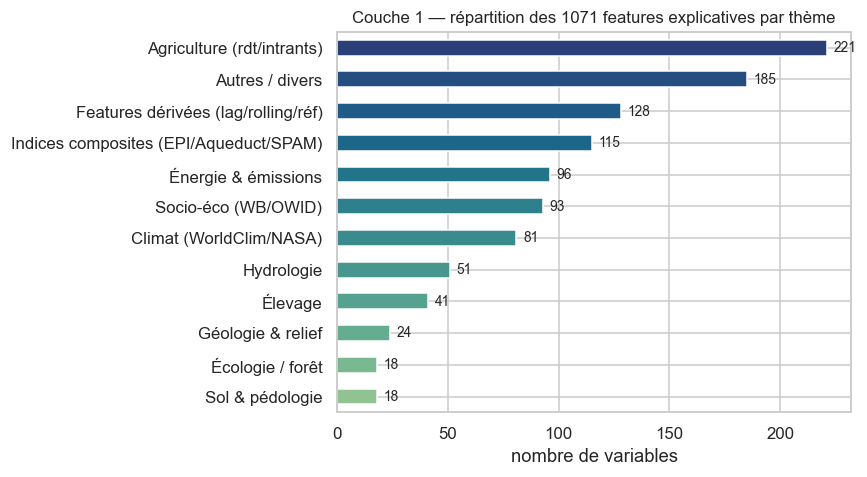

Les features couvrent les 8 grands compartiments du système-Terre + le socio-éco (entrées de la Couche 2).


In [10]:
# --- Catégorisation des 1071 features par thème (mots-clés sur les noms de colonnes) ---
cats = {
 'Climat (WorldClim/NASA)':      ['temp','t_annual','precip','p_annual','wind','solar_rad','vapor','bio_','thermal','enso','nao','amo','pdo','radiation','humid','moisture'],
 'Sol & pédologie':              ['soil','clay','silt','sand','ph','organic_carbon','bilan_sol','nutrient'],
 'Géologie & relief':            ['elevation','slope','aspect','rough','fault','seismic','volcano','tectonic','eq_','mineral','mrds'],
 'Hydrologie':                   ['river','lake','coast','freshwater','groundwater','water','irrig'],
 'Agriculture (rdt/intrants)':   ['yield_','cereals_','area_ha','engrais','pesticide','terres','arable','agri','culture','prod_t','ecocrop','suitability'],
 'Élevage':                      ['carcass','milk','eggs','livestock','cattle','chicken','pig','sheep','aquacult','meat'],
 'Énergie & émissions':          ['energy','coal','oil','gas','wind_gen','hydro','co2','methane','ch4','n2o','emission','powerplant','electric','ember'],
 'Écologie / forêt':             ['forest','tree_cover','hansen','biodiv','species','npp','fauna','wood'],
 'Socio-éco (WB/OWID)':          ['gdp','hdi','pop','birth','death','urban','inflation','unempl','gini','pover','life_exp','child_mort','migration','internet','mobile','health','hospital','schooling','religion','muslim','christian'],
 'Indices composites (EPI/Aqueduct/SPAM)': ['epi_','aqueduct','spam_','ecocrop','suitabil','wdpa','gbif','wahis','ember','hdx'],
 'Features dérivées (lag/rolling/réf)':    ['_lag','_roll','_ref','_raw','_score','_z','_norm','_oof','_pct','_idx','_ratio'],
}
ids = {'ISO','Annee','T_ref','P_ref','cluster'}
feats = [c for c in C1.columns if c not in ids and not c.startswith('target_')]
seen, counts = set(), {}
for cat, kw in cats.items():
    uniq = [c for c in feats if c not in seen and any(k in c.lower() for k in kw)]
    seen.update(uniq); counts[cat] = len(uniq)
counts['Autres / divers'] = len([c for c in feats if c not in seen])

s = pd.Series(counts).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
s.plot.barh(ax=ax, color=sns.color_palette('crest', len(s)))
ax.set_title(f"Couche 1 — répartition des {len(feats)} features explicatives par thème", fontsize=11)
ax.set_xlabel("nombre de variables")
for i, v in enumerate(s.values):
    ax.text(v + 3, i, str(v), va='center', fontsize=9)
plt.tight_layout(); plt.savefig('notebooks_presentation/figures/nb1_features_par_theme.png', bbox_inches='tight')
plt.show()
print("Les features couvrent les 8 grands compartiments du système-Terre + le socio-éco (entrées de la Couche 2).")

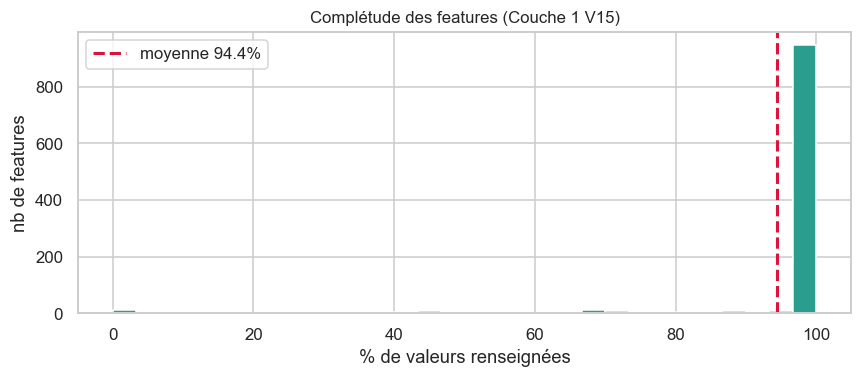

Complétude moyenne : 94.4%  —  960 features remplies à >90%, 61 features <50% (à imputer).


In [11]:
# --- Qualité : complétude des features (taux de remplissage) ---
fill = 1 - C1[feats].isna().mean()
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(fill.values * 100, bins=30, color='#2a9d8f', edgecolor='white')
ax.axvline(fill.mean()*100, color='crimson', ls='--', lw=2, label=f"moyenne {fill.mean()*100:.1f}%")
ax.set_title("Complétude des features (Couche 1 V15)", fontsize=11)
ax.set_xlabel("% de valeurs renseignées"); ax.set_ylabel("nb de features"); ax.legend()
plt.tight_layout(); plt.savefig('notebooks_presentation/figures/nb1_completude.png', bbox_inches='tight')
plt.show()
print(f"Complétude moyenne : {fill.mean()*100:.1f}%  —  "
      f"{(fill>0.9).sum()} features remplies à >90%, {(fill<0.5).sum()} features <50% (à imputer).")

## 5. Couche 2 — le pipeline « Le Sang »

Pipeline dédié dans `couche2/`, même logique, clé `(Pays, Année)` :

```
 download_data.py            clean_merge.py                dataset_couche2.csv
   COLLECTE          →        NETTOYAGE + FUSION      →     (14 322 lignes, 240 pays,
 World Bank, FAO,            harmonisation ISO,             1960-2025)
 Project Tycho              indicateurs alignés
```

**Indicateurs produits :** natalité, fécondité, mortalité (infantile / <5 ans / brute), densité,
population, **carence alimentaire** (malnutrition, FAO), migration nette.

In [12]:
# --- Couche 2 : aperçu et complétude des indicateurs ---
ind = ['Natalite_pour1000','Fecondite_enf_par_femme','MortInfantile_pour1000','MortMoins5ans_pour1000',
       'MortBrute_pour1000','Densite_hab_km2','Population','Carence_pct','MigrationNette']
comp = (1 - C2[ind].isna().mean()).sort_values()*100
print("Complétude des indicateurs Couche 2 (%) :")
for k, v in comp.items(): print(f"  {v:5.1f}%  {k}")
print(f"\nCouche 2 : {C2.shape[0]} lignes, {C2['Code_Pays'].nunique()} pays, "
      f"{int(C2['Annee'].min())}-{int(C2['Annee'].max())}, {len(C2['Region'].unique())} régions")

Complétude des indicateurs Couche 2 (%) :
   26.7%  Carence_pct
   82.6%  MortInfantile_pour1000
   82.8%  MortMoins5ans_pour1000
   86.0%  Densite_hab_km2
   98.3%  Fecondite_enf_par_femme
   98.3%  Natalite_pour1000
   98.3%  MortBrute_pour1000
   98.3%  Population
  100.0%  MigrationNette

Couche 2 : 14322 lignes, 217 pays, 1960-2025, 7 régions


## 6. Anti-fuite de données (méthodologie de rigueur)

Deux garde-fous, codés dans `config.py` de chaque couche :

1. **Split par pays** (`GroupShuffleSplit` sur l'ISO), **pas** par année. Beaucoup de features sont
   ~constantes par pays (géographie, géologie) : un split temporel laisserait le modèle *mémoriser*
   chaque pays (R² artificiellement = 1.0). En testant sur des **pays jamais vus**, le R² reflète la
   vraie généralisation.
2. **Blacklist explicite** (`build_blacklist`) : pour chaque cible, on retire la colonne source brute,
   les autres cibles, et — pour les cibles **Couche 2** — **toutes** les variables socio-économiques
   (PIB, HDI, mortalités voisines…). On force ainsi le modèle à expliquer la démographie **par
   l'environnement seul**.

> C'est ce qui rend le résultat phare honnête : prédire la **natalité à R²≈0.95 sans aucune variable
> socio-économique**, juste avec le climat / les sols / les rendements.

## 7. État d'avancement (au moment de la soutenance)

**✅ Fait**
- Couche 1 « Planète » assemblée jusqu'à **V15** (8 400 lignes, 240 pays, 1 071 features, 81 cibles).
- Couche 2 « Sang » assemblée (14 322 lignes, indicateurs démographie/santé).
- Pipeline reproductible (collecte → nettoyage → enrichissement → fusion) documenté et versionné.
- Méthodologie anti-fuite en place (split par pays + blacklist).
- Modèles entraînés sur 62 cibles (résultats dans le notebook 3).

**🚧 En cours / limites**
- Quelques cultures peu prévisibles par climat seul (mangue, pois chiche…) — assumé.
- Sous-couche « Géologie » construite mais pas encore intégrée au tableau de résultats principal.
- Couches « supérieures » (lien C1→C2) : jointure analytique en place, modèle inter-couches au notebook 3.

**➡️ Suite :** Notebook 2 — **exploration** (graphiques justifiés + hypothèses), puis Notebook 3 —
**entraînement & résultats** (features, matrices de corrélation, R² par sous-couche).